In [1]:
# Here I want to test make map from catalog, and catalog is from healpix points
%cd /home/yshi/work/work_gravity/catalog2map/

import numpy as np
import pyccl as ccl
import healpy as hp
from tqdm import tqdm
from matplotlib import pyplot as plt
# from akra_full import KappaRec_sphere
from gaussianfield import get_cl
from interp_tools import lonlat2hpmap, catalog2map


/home/yshi/work/work_gravity/catalog2map


In [2]:
### generate map but the ell must smaller than nside_in*2
np.random.seed(0)
nside_in = 128
lmax = int(nside_in*1.5)

### nside_out should be larger than nside_in
nside_out = nside_in*4
l = np.arange(lmax, dtype=float)
cls = np.zeros_like(l)
cls[1:] = l[1:]**-2.
cls[0] = 0.0
cls[1] = 0.0
# cls[:120] = 0.0
alm_skymap = hp.synalm(cls)
skymap = hp.alm2map(alm_skymap, nside=nside_out)
# hp.mollview(skymap)


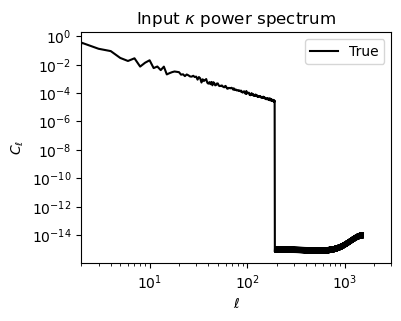

In [3]:
cl_true = hp.anafast(skymap)
plt.figure(figsize=(4, 3), dpi=100)
plt.loglog(cl_true, label="True", color="black")
plt.xlabel("$\ell$")
plt.ylabel("$C_\ell$")
# plt.ylim(1e-11, 1e-7)
plt.xlim(2,3000)
plt.title("Input $\kappa$ power spectrum")
plt.legend()
plt.show()

In [4]:
mask0 = np.ones(hp.nside2npix(nside_out), dtype=bool)
# mask0[100] = 0

In [5]:
resolution = hp.nside2resol(nside_out, arcmin=True)
print(resolution, "arcmin")

ipix = np.arange(hp.nside2npix(hp.get_nside(skymap)))
ipix = ipix[mask0==1]
ra0, dec0 = hp.pix2ang(nside_out, ipix, lonlat=True)
print(ra0.shape, dec0.shape)
cat_obs = skymap[mask0==1]


6.870972823634812 arcmin
(3145728,) (3145728,)


In [6]:
## generate catalog
from astropy import units as u
N_p = 1
lon_list = ra0
lat_list = dec0 
catlog_list = cat_obs
### N_p is the number of points in a healpix pixel

# N_p = 2
# from astropy_healpix import HEALPix
# hp0 = HEALPix(nside=nside_out)
# skymap_list = np.copy(skymap)

if N_p > 1:
    for i in range(N_p-1):
        dx, dy = np.random.uniform(0,1, len(ipix)), np.random.uniform(0,1, len(ipix))
        ra_p_i, dec_p_i = hp0.healpix_to_lonlat(ipix, dx=dx, dy=dy)
        lon_list = np.append(lon_list, ra_p_i.to(u.deg).value)
        lat_list = np.append(lat_list, dec_p_i.to(u.deg).value)
        catlog_list = np.append(catlog_list, cat_obs)
print(lon_list.shape, lat_list.shape, catlog_list.shape)



(3145728,) (3145728,) (3145728,)


In [7]:
np.pi/(np.deg2rad(0.2))

900.0

In [8]:
from flat_sky_tools import get_grid
lon0 = 50 #center of the map (RA)
lat0 = 0. #center of the map (Dec)
nx = 100 #grid size in x direction
ny = 100 #grid size in y direction
# nside_out = 1024 
dx = dy = 0.2 #degrees

remove_pixels = int(nx//5-1)
lon1, lat1, (x1, y1) = get_grid(lon0, lat0, dx, nx, dy, ny)


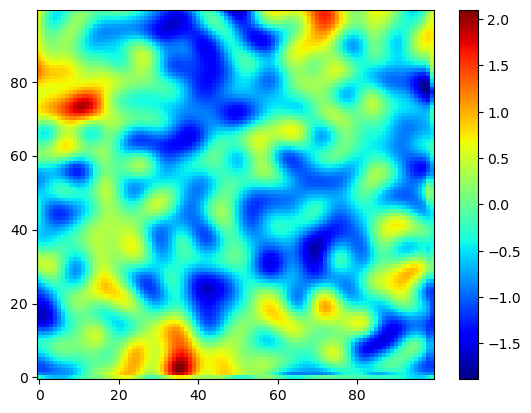

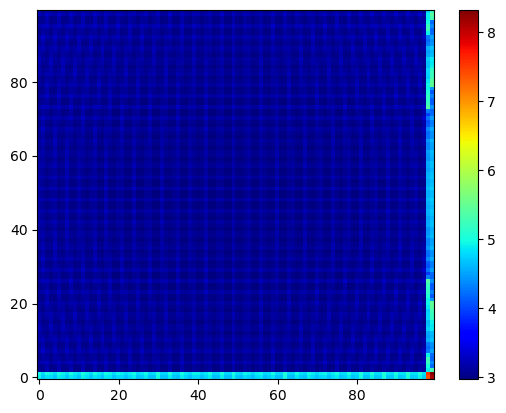

In [9]:
#### 根据给定的中心坐标、分辨率和网格大小，将经纬度catalog转换为平面坐标
skymap_unnorm, weight_flat = catalog2map(64, lon_list, lat_list, catlog_list, lon0, lat0, x1, y1, dx, nx, dy, ny, window='cic')
valid = weight_flat>0
skymap_flat = np.zeros_like(skymap_unnorm)
skymap_flat[valid] = skymap_unnorm[valid]/weight_flat[valid]
skymap_flat = skymap_flat.reshape(nx,ny)

plt.imshow(skymap_flat[::-1].T, cmap="jet", origin="lower", aspect='auto')
plt.colorbar()
plt.show()
plt.imshow(weight_flat[::-1].T, cmap="jet", origin="lower", aspect='auto')
plt.colorbar()
plt.show()

In [10]:
from interp_tools import lonlat2hpmap
skymap_new1, ipix = lonlat2hpmap(lon0, lat0, x1, y1, skymap_flat, lon=lon1, lat=lat1, nside=nside_out, return_ipix=True)
npix = hp.nside2npix(nside_out)

In [11]:
# lmax = nside_in*2
# l = np.arange(lmax, dtype=float)

# kN = np.pi/np.deg2rad(dx)
# win = np.sinc( 0.5 * l / kN) **4
# alm1 = hp.map2alm(skymap_new1, lmax=lmax)
# hp.almxfl(alm1, 1/np.sqrt(win), inplace=True)

# ### if N_p >1
# if N_p > 1:
#     win2 = hp.pixwin(hp.get_nside(skymap), pol=False, lmax=lmax)
#     hp.almxfl(alm1, 1/np.sqrt(win2), inplace=True)
    
# skymap_new = np.zeros(npix, dtype=float)
# skymap_new[ipix] = hp.alm2map(alm1, nside=nside_out)[ipix]


In [12]:
skymap0 = np.zeros_like(skymap)
skymap0[ipix] = skymap[ipix]

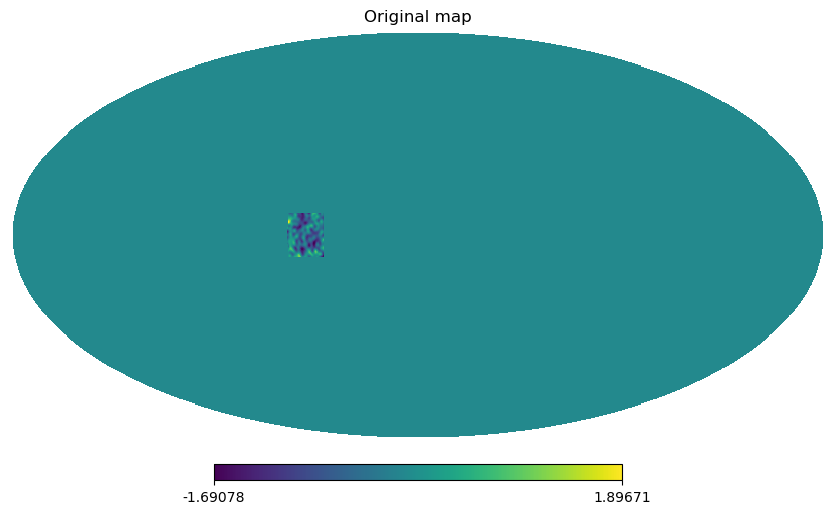

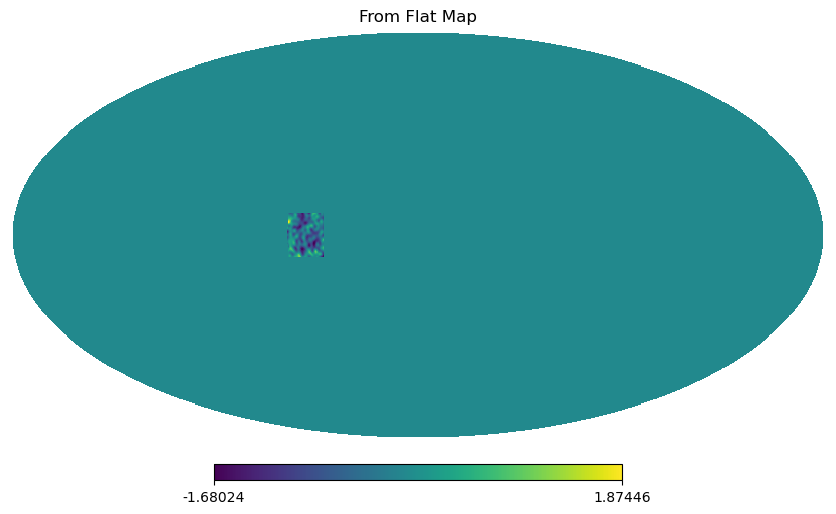

In [13]:
hp.mollview(skymap0, title="Original map")
hp.mollview(skymap_new1, title="From Flat Map")

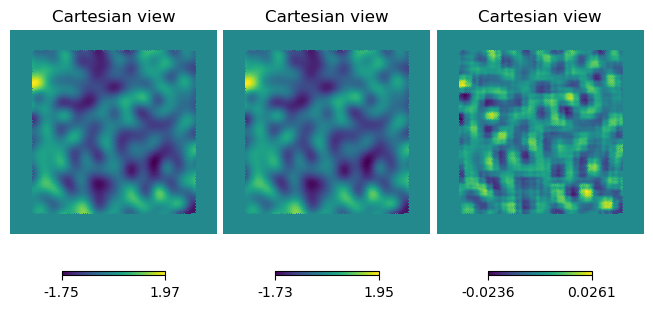

In [14]:
hp.cartview(skymap0, lonra=[lon1.min(), lon1.max()], latra=[lat1.min(), lat1.max()], sub=131)
hp.cartview(skymap_new1, lonra=[lon1.min(), lon1.max()], latra=[lat1.min(), lat1.max()], sub=132)
hp.cartview(skymap0-skymap_new1, lonra=[lon1.min(), lon1.max()], latra=[lat1.min(), lat1.max()], sub=133)

In [15]:
d_lat = np.abs(lat1.T[int(-remove_pixels), int((nx -remove_pixels))] - lat0)
# d_lat

lat0_unique = np.linspace(0., 90.-1e-6, np.ceil(90/(d_lat*1.6)).astype(int))
lat0_unique = np.unique(np.concatenate([-lat0_unique[::-1], lat0_unique]))
print(lat0_unique)

from tqdm import tqdm

from interp_tools import get_lonRange
lon0_list = []
lat0_list = []
lon_arrays = []
lat_arrays = []
x_arrays = []
y_arrays = []

iter_i = 0
npix = nx*ny
for lat0 in tqdm(lat0_unique):
    lon0 = 1.e-6
    # lon0 = 0.
    iter_i = 0
    if iter_i==0:
        if lat0 == 0.: print(lat0, lon0_unique)
        lon1, lat1, (x1,y1) = get_grid(lon0, lat0, dx, nx, dy, ny)
        d_lon = get_lonRange(lon1[remove_pixels:-remove_pixels, remove_pixels:-remove_pixels])[0] 
        lon0_unique = np.linspace(0., 360.-1e-6, np.ceil(360./(d_lon*0.95)).astype(int), endpoint=False)[1:]
        x_arrays.append(x1)
        y_arrays.append(y1)
        lon0_list.append(lon0)
        lat0_list.append(lat0)
        lon_arrays.append(lon1)
        lat_arrays.append(lat1)
        iter_i += 1
        
    if np.abs(lat0) > 89.9:
        continue
    for lon0 in lon0_unique:
        # lat0 = lat0
        lon1, lat1, (x1,y1) = get_grid(lon0, lat0, dx, nx, dy, ny)

        x_arrays.append(x1)
        y_arrays.append(y1)
        lon0_list.append(lon0)
        lat0_list.append(lat0)
        lon_arrays.append(lon1)
        lat_arrays.append(lat1)
        iter_i += 1

[-89.999999   -78.74999913 -67.49999925 -56.24999938 -44.9999995
 -33.74999963 -22.49999975 -11.24999988   0.          11.24999988
  22.49999975  33.74999963  44.9999995   56.24999938  67.49999925
  78.74999913  89.999999  ]


 47%|████▋     | 8/17 [00:00<00:00, 65.71it/s]

0.0 [ 11.61290319  23.22580639  34.83870958  46.45161277  58.06451597
  69.67741916  81.29032235  92.90322555 104.51612874 116.12903194
 127.74193513 139.35483832 150.96774152 162.58064471 174.1935479
 185.8064511  197.41935429 209.03225748 220.64516068 232.25806387
 243.87096706 255.48387026 267.09677345 278.70967665 290.32257984
 301.93548303 313.54838623 325.16128942 336.77419261 348.38709581]


100%|██████████| 17/17 [00:00<00:00, 63.85it/s]


100%|██████████| 353/353 [07:11<00:00,  1.22s/it]


(array([], dtype=int64),)


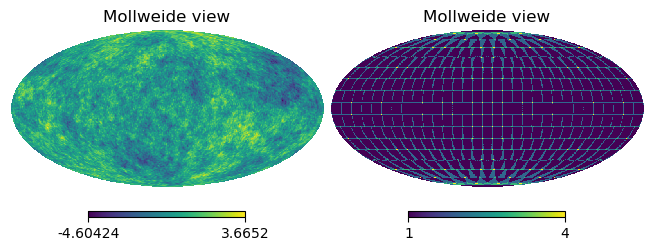

In [16]:
### Test the lonlat to healpix map covers all the pixels
nside_ll = 256 

hpmaps = []
ipixs = []
remove_pixs = int(nx//5-1)
for i in tqdm(range(len(lon0_list))):
    skymap_flat, weight_flat = catalog2map(64, lon_list, lat_list, catlog_list, lon0_list[i], lat0_list[i], x_arrays[i], y_arrays[i], dx, nx, dy, ny)
    flat_mask = np.zeros_like(weight_flat)
    flat_mask[weight_flat>0] = 1
    skymap_flat2 = np.zeros_like(skymap_flat)
    skymap_flat2[flat_mask==1] = skymap_flat[flat_mask==1]/weight_flat[flat_mask==1]
    hpmap, ipix = lonlat2hpmap(lon0_list[i], lat0_list[i], x_arrays[i], y_arrays[i], skymap_flat2, lon_arrays[i], lat_arrays[i], nside=nside_ll, return_ipix=True, remove_pixs=remove_pixs)
    hpmaps.append(hpmap)
    ipixs.append(ipix)

recmap = np.zeros(12*nside_ll**2)
counts = np.zeros(12*nside_ll**2)

for hpmap, pix_i in zip(hpmaps, ipixs):
    np.add.at(recmap, pix_i, hpmap[pix_i])
    np.add.at(counts, pix_i, 1)
recmap[counts>0] /= counts[counts>0]

hp.mollview(recmap, sub=121)
hp.mollview(counts, sub=122)

print(np.where(counts==0))

In [17]:
lmax = nside_in*2
l = np.arange(lmax, dtype=float)

kN = np.pi/np.deg2rad(dx)
win = np.sinc( 0.5 * l / kN) **4
alm1 = hp.map2alm(recmap, lmax=lmax)
hp.almxfl(alm1, 1/np.sqrt(win), inplace=True)

### if N_p >1
if N_p > 1:
    win2 = hp.pixwin(hp.get_nside(skymap), pol=False, lmax=lmax)
    hp.almxfl(alm1, 1/np.sqrt(win2), inplace=True)
    
recmap2 = hp.alm2map(alm1, nside=nside_out)


In [18]:
cl_true = hp.anafast(skymap, lmax=lmax)
cl_rec = hp.anafast(recmap2, lmax=lmax)
print(skymap.shape, recmap2.shape)

rl = hp.anafast(recmap2, skymap, lmax=lmax)/np.sqrt(cl_true*cl_rec)

(3145728,) (3145728,)


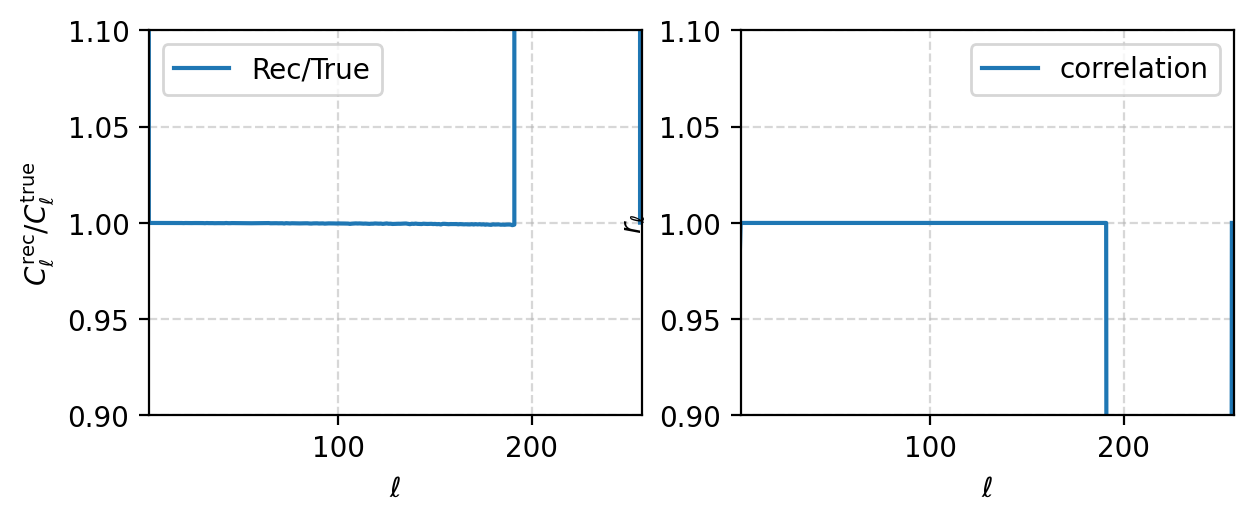

In [19]:
lmax = len(cl_true)
l = np.arange(lmax, dtype=float)
kN = np.pi/np.deg2rad(dx)

### if N_p is not 1, the pixwin should be deconvolved
# pixwin = hp.pixwin(nside=nside_out, lmax=lmax)

fig, ax = plt.subplots(1, 2, figsize=(7, 2.5), dpi=200)
ax[0].plot(cl_rec/cl_true, label="Rec/True")
# ax[0].plot(1/pixwin, label="PixWin", ls='--')
ax[0].set_ylabel(r'$C_\ell^{\mathrm{rec}}/C_\ell^{\mathrm{true}}$')
ax[0].set_xlabel(r'$\ell$')
ax[0].set_xlim(2, lmax)
ax[0].set_ylim(0.9, 1.1)
ax[0].grid(ls="--", alpha=0.5)
ax[0].legend(fontsize=10)

ax[1].plot(rl, label='correlation', ls='solid')
ax[1].set_ylabel(r'$r_\ell$')
ax[1].set_xlabel(r'$\ell$')
ax[1].set_xlim(2, lmax)
ax[1].set_ylim(0.9, 1.1)
ax[1].legend(fontsize=10)
ax[1].grid(ls="--", alpha=0.5)


In [20]:
skymap.shape, recmap2.shape

((3145728,), (3145728,))

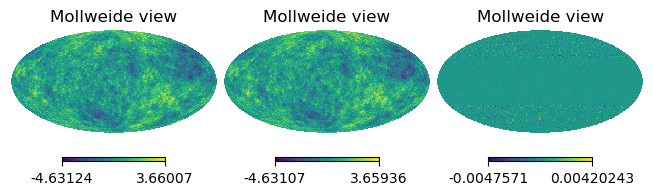

In [21]:
hp.mollview(skymap, sub=131)
hp.mollview(recmap2, sub=132)
hp.mollview(skymap-recmap2, sub=133)